In [3]:
print("all ok")

all ok


In [1]:
from dotenv import load_dotenv
load_dotenv()
import os
os.environ["Gemini"] = os.¸("GROQ_API_KEY")

Bad pipe message: %s [b'\x86\xed\x9f$\x1di\x9d:\x80\xbd\xc2\x9eT\x83F\xff"\xad\x00\x01|\x00\x00\x00\x01\x00\x02\x00\x03\x00\x04\x00\x05\x00\x06\x00\x07\x00\x08\x00\t\x00\n\x00\x0b\x00\x0c\x00\r\x00\x0e\x00\x0f\x00\x10\x00\x11\x00\x12\x00\x13\x00\x14\x00\x15\x00\x16\x00\x17\x00\x18\x00\x19\x00\x1a\x00\x1b\x00/\x000\x001\x002\x003\x004\x005\x006\x007\x008\x009\x00:\x00;\x00<\x00=\x00>\x00?\x00@\x00A\x00B\x00C\x00D\x00E\x00F\x00g\x00h\x00i\x00j\x00k\x00l\x00m\x00\x84\x00\x85\x00\x86\x00\x87\x00\x88\x00\x89\x00\x96\x00', b"\x98\x00\x99\x00\x9a\x00\x9b\x00\x9c\x00\x9d\x00\x9e\x00\x9f\x00\xa0\x00\xa1\x00\xa2\x00\xa3\x00\xa4\x00\xa5\x00\xa6\x00\xa7\x00\xba\x00\xbb\x00\xbc\x00\xbd\x00\xbe\x00\xbf\x00\xc0\x00\xc1\x00\xc2\x00\xc3\x00\xc4\x00\xc5\x13\x01\x13\x02\x13\x03\x13\x04\x13\x05\xc0\x01\xc0\x02\xc0\x03\xc0\x04\xc0\x05\xc0\x06\xc0\x07\xc0\x08\xc0\t\xc0\n\xc0\x0b\xc0\x0c\xc0\r\xc0\x0e\xc0\x0f\xc0\x10\xc0\x11\xc0\x12\xc0\x13\xc0\x14\xc0\x15\xc0\x16\xc0\x17\xc0\x18\xc0\x19\xc0#\xc0$\xc0%\xc0&\

In [5]:
model = "deepseek-r1-distill-llama-70b"

In [6]:
from langchain_groq import ChatGroq

In [7]:
llm=ChatGroq(
    model=model)

In [8]:
print(llm.invoke("What is the capital of France?").content)

<think>
Okay, so I need to figure out the capital of France. Hmm, I'm not entirely sure, but I think it's a pretty well-known city. Let me try to recall. I remember learning about some countries and their capitals in school, but I might be mixing a few up. 

Wait, France is in Europe, right? So the capital should be a major European city. I think Paris might be the capital. Yeah, that sounds familiar. But I'm not 100% certain. Let me think of other clues. The Eiffel Tower is in Paris, and I've heard that Paris is often called the capital of France. Also, when I think of French government, I imagine it's based in Paris. 

Are there any other possible cities? Maybe Lyon or Marseille? No, those are other big cities in France, but I don't think they're the capital. The capital is usually the largest city and the administrative center. Paris is definitely the largest city in France and a global center for fashion, art, and culture. 

I remember hearing that London is the capital of England,

In [9]:
import operator
from typing import List
from langgraph.graph.message import add_messages
from pydantic import BaseModel , Field
from typing import TypedDict, Annotated, Sequence
from langchain_core.messages import BaseMessage
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate, PromptTemplate

from langchain_core.tools import tool
from langchain_core.messages import HumanMessage, AIMessage
from langgraph.graph import StateGraph,MessagesState,START,END
from langgraph.prebuilt import ToolNode

In [10]:
def call_model(state: MessagesState) -> dict:
    messages = state['messages']
    response = llm.invoke(messages)
    return {"messages": [AIMessage(content=response.content)]}


In [11]:
state=MessagesState(messages=[
    HumanMessage(content="What is the capital of France?"),])

In [ ]:
# from langchain_core.messages import AnyMessage
# class MessagesState(TypedDict):
#     messages: Annotated[list[AnyMessage], add_messages]


class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], operator.add]

In [13]:
state

{'messages': [HumanMessage(content='What is the capital of France?', additional_kwargs={}, response_metadata={})]}

In [14]:
workflow = StateGraph(MessagesState)
workflow.add_node("call_model", call_model)
workflow.add_edge(START, "call_model")
workflow.add_edge("call_model", END)

In [15]:
app = workflow.compile()

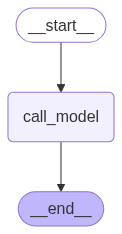

In [16]:
from IPython.display import display, Image
display(Image(app.get_graph().draw_mermaid_png()))

In [17]:
# Correct usage
state = {"messages": [HumanMessage(content="What is the capital of France?")]}
result = app.invoke(state)
print(result['messages'][-1].content)

<think>

</think>

The capital of France is Paris.


In [18]:
@tool
def search(query:str):
    """this is my custom tool for searching a weather"""
    if "delhi" in query.lower():
        return "the temp is 45 degree and sunny"
    return "the temp is 25 degree and cloudy"

In [19]:
search.invoke("What is the weather in Delhi?")

'the temp is 45 degree and sunny'

In [20]:
search.invoke("What is the weather in ohio?")

'the temp is 25 degree and cloudy'

In [21]:
tools = [search]

In [22]:
llm_with_tool = llm.bind_tools(tools)

In [23]:
response = llm_with_tool.invoke("What is the weather in Delhi?")

In [24]:
response.tool_calls

[{'name': 'search',
  'args': {'query': 'Delhi weather'},
  'id': '8hmwwg7aw',
  'type': 'tool_call'}]

In [25]:
def call_model2(state: MessagesState) -> dict:
    messages = state['messages']
    response = llm_with_tool.invoke(messages)
    return {"messages": [response]}

In [26]:
call_model(state  )

{'messages': [AIMessage(content='<think>\n\n</think>\n\nThe capital of France is Paris.', additional_kwargs={}, response_metadata={})]}

In [27]:
llm_with_tool.invoke("What is the weather in Delhi?")

AIMessage(content='', additional_kwargs={'reasoning_content': 'Okay, the user is asking about the weather in Delhi. I need to use the search tool to find this information.\n\nFirst, I\'ll specify the function name as "search" since that\'s the tool provided.\n\nNext, I\'ll prepare the arguments. The tool requires a "query" parameter, so I\'ll set that to "weather in Delhi".\n\nI\'ll structure the arguments as a JSON object with the query inside.\n\nFinally, I\'ll format the entire tool call within the <tool_call> XML tags as specified.\n', 'tool_calls': [{'id': '4e913z40h', 'function': {'arguments': '{"query":"weather in Delhi"}', 'name': 'search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 134, 'prompt_tokens': 132, 'total_tokens': 266, 'completion_time': 0.487272727, 'prompt_time': 0.015795672, 'queue_time': 0.054182048, 'total_time': 0.503068399}, 'model_name': 'deepseek-r1-distill-llama-70b', 'system_fingerprint': 'fp_76307ac09b', 'finish_reason

In [28]:
def router_function(state: MessagesState) -> str:
    messages = state['messages']
    last_message = messages[-1]
    if last_message.tool_calls:
        return "tools"

    return END

In [29]:
tool_node = ToolNode(tools)

In [30]:
workflow2 = StateGraph(MessagesState)\
    .add_node("llm_with_tool", call_model2)\
        .add_node("mytools", tool_node)\
            .add_edge(START, "llm_with_tool")\
                .add_conditional_edges("llm_with_tool",
                                      router_function,
                                      {"tools": "mytools",
                                      END: END}
                                      )


In [31]:
app2=workflow2.compile()

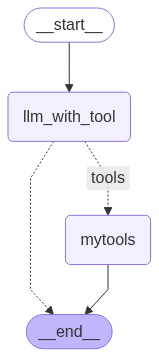

In [32]:
from IPython.display import Image, display
display(Image(app2.get_graph().draw_mermaid_png()))

In [33]:
response=app2.invoke({"messages":["what is a weather in bengraluru?"]})

In [34]:
response["messages"]

[HumanMessage(content='what is a weather in bengraluru?', additional_kwargs={}, response_metadata={}, id='e6cc1846-65f1-40a6-aa1e-d76081e3ef83'),
 AIMessage(content='', additional_kwargs={'reasoning_content': 'Okay, the user is asking about the weather in Bengaluru. I should use the search tool I have to find this information.\n\nFirst, I need to structure the function call correctly. The function is named "search" and requires a query parameter. So, I\'ll set the name to "search" and the query to "Bengaluru weather".\n\nI should make sure the JSON is correctly formatted. Let me double-check the syntax to avoid any mistakes.\n\nAlright, I\'m ready to make the call.\n', 'tool_calls': [{'id': 'r85epkv9g', 'function': {'arguments': '{"query":"Bengaluru weather"}', 'name': 'search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 130, 'prompt_tokens': 135, 'total_tokens': 265, 'completion_time': 0.585403912, 'prompt_time': 0.008698487, 'queue_time': 0.067987

In [35]:
workflow2.add_edge("mytools","llm_with_tool")

Adding an edge to a graph that has already been compiled. This will not be reflected in the compiled graph.


In [36]:
app3=workflow2.compile()

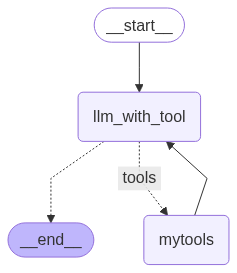

In [37]:
from IPython.display import Image, display
display(Image(app3.get_graph().draw_mermaid_png()))

In [38]:
for output in app3.stream({"messages":["what is a weather in new delhi?"]}):
    for key,value in output.items():
        print(f"here is output from {key}")
        print("_______")
        print(value)
        print("\n")


here is output from llm_with_tool
_______
{'messages': [AIMessage(content='', additional_kwargs={'reasoning_content': 'Okay, the user is asking about the weather in New Delhi. I need to use the provided tool to find this information. The tool is called "search" and it requires a query parameter.\n\nFirst, I\'ll structure the function call with the correct function name and the appropriate argument. The query should be specific, so I\'ll set it to "New Delhi weather" to get accurate results.\n\nI\'ll make sure the JSON is properly formatted and wrap it within the <tool_call> tags as specified. This should provide the user with the current weather information they\'re seeking.\n', 'tool_calls': [{'id': 'hyv1xdeey', 'function': {'arguments': '{"query":"New Delhi weather"}', 'name': 'search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 144, 'prompt_tokens': 134, 'total_tokens': 278, 'completion_time': 0.692754821, 'prompt_time': 0.008812445, 'queue_time'

In [39]:
from langgraph.checkpoint.memory import MemorySaver

In [42]:
memory=MemorySaver()

In [40]:
workflow3=StateGraph(MessagesState)

workflow3.add_node("llmwithtool",call_model)

workflow3.add_node("mytools",tool_node)

workflow3.add_edge(START,"llmwithtool")

workflow3.add_conditional_edges("llmwithtool",
                                router_function,
                                {"tools":"mytools",
                                 END:END})

workflow3.add_edge("mytools","llmwithtool")

In [43]:
app4=workflow3.compile(checkpointer=memory)

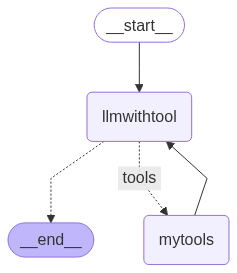

In [44]:
from IPython.display import Image, display
display(Image(app4.get_graph().draw_mermaid_png()))

In [45]:
config={"configurable": {"thread_id": "1"}}

In [46]:
events=app4.stream(
    {"messages":["what is a weather in new delhi?"]},config=config,stream_mode="values"
    )

In [47]:
for event in events:
    event["messages"][-1].pretty_print()

================================ Human Message =================================

what is a weather in new delhi?
================================== Ai Message ==================================

<think>
Okay, so I need to figure out what the weather is like in New Delhi. I'm not exactly sure how to start, but I think I can break it down. First, I should probably consider the general climate of New Delhi. I remember hearing it's a humid subtropical climate, but I'm not entirely sure what that means. Maybe it has hot summers and cool winters?

I think New Delhi experiences different seasons, so I should look into that. I recall that India has a monsoon season, so that must play a role. Let me think about the seasons one by one. Starting with summer, I believe it's quite hot there. Maybe from March to June? I think the temperatures can get really high, maybe even above 40 degrees Celsius during the peak. That sounds really hot, especially with the humidity.

Then comes the monsoon season

In [48]:
events=app4.stream(
    {"messages":["what is a weather in indore?"]},config=config,stream_mode="values"
    )

In [ ]:
for event in events:
    event["messages"][-1].pretty_print()

================================ Human Message =================================

what is a weather in indore?
================================== Ai Message ==================================

<think>
Okay, the user previously asked about the weather in New Delhi, and now they're asking about Indore. I need to provide a similar structure but tailored to Indore's specific climate. First, I should recall what type of climate Indore has. I think it's a tropical savanna climate, which typically has three main seasons: summer, monsoon, and winter. 

I should break down each season with temperature ranges and rainfall. For summer, Indore gets pretty hot, maybe around 30-45°C. Monsoon season would bring significant rainfall, possibly leading to flooding. Winters are mild, probably around 10-25°C. 

I should also mention any unique aspects, like the southwest monsoon bringing most of the rainfall. It's important to highlight any extreme weather events, such as heatwaves in summer or heavy down

Bad pipe message: %s [b'\xa7T\xb5\xd2V\x12\xd9`]1X[\x05\xceR+\xefz\x00\x01|\x00\x00\x00\x01\x00\x02\x00\x03\x00\x04\x00\x05\x00\x06\x00\x07\x00\x08\x00\t\x00\n\x00\x0b\x00\x0c\x00\r\x00\x0e\x00\x0f\x00\x10\x00\x11\x00\x12\x00\x13\x00\x14\x00\x15\x00\x16\x00\x17\x00\x18\x00\x19\x00\x1a\x00\x1b\x00/\x000\x001\x002\x003\x004\x005\x006\x007\x008\x009\x00:\x00;\x00<\x00=\x00>\x00?\x00@\x00A\x00B\x00C\x00D\x00E\x00F\x00g\x00h\x00i\x00j\x00k\x00l\x00m\x00\x84\x00\x85\x00\x86\x00\x87\x00\x88\x00\x89\x00\x96\x00\x97\x00\x98\x00\x99\x00\x9a\x00\x9b\x00\x9c\x00\x9d\x00\x9e\x00\x9f\x00\xa0\x00\xa1\x00\xa2\x00\xa3\x00\xa4\x00\xa5\x00\xa6\x00\xa7\x00\xba\x00\xbb\x00\xbc\x00\xbd\x00\xbe\x00\xbf\x00\xc0\x00\xc1\x00\xc2\x00\xc3\x00\xc4\x00\xc5\x13\x01\x13\x02\x13\x03\x13\x04\x13\x05\xc0\x01\xc0\x02\xc0\x03\xc0\x04\xc0\x05\xc0\x06\xc0\x07\xc0\x08\xc0\t\xc0\n\xc0\x0b\xc0\x0c']
Bad pipe message: %s [b"e\x9e\n\\r\xb4\xaa\xcd\x9f\x07\x86g\x8b\\\xb2'-\xec\x00\x01|\x00\x00\x00\x01\x00\x02\x00\x03\x00\x04\x00\